In [1]:
# here we instruct tune GPT2 model to be a QnA chat model

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, GPT2Tokenizer
from datasets import load_dataset

import textwrap

In [8]:
# load a pretrained GPT2-model and tokenizer
gpt2  = AutoModelForCausalLM.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [9]:
seq_len = 256
batch_size = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

Import text data

In [10]:
dataset = load_dataset('THUDM/webglm-qa')
dataset

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'references'],
        num_rows: 43579
    })
    validation: Dataset({
        features: ['question', 'answer', 'references'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['question', 'answer', 'references'],
        num_rows: 400
    })
})

In [13]:
dataset['train'][0]

{'question': 'in football whats the point of wasting the first two plays with a rush - up the middle - not regular rush plays i get those',
 'answer': 'The point of wasting the first two plays with a rush up the middle is to take advantage of the 40 second play clock and the two minute warning in professional and college football games. By running the ball directly up the middle, the offense hopes to be able to block everyone up and the running back can make a person miss and end up in the end zone[2]. Running up the middle is also the shortest path to the end zone, so it is often designed to move defensive players out of the way[3]. Additionally, running the ball up the middle enough times will cause linebackers and defensive backs to run toward the line of scrimmage, creating the perfect opportunity to throw the ball over their heads or in vacated areas[4]. This strategy is used to keep possession of the ball as long as possible rather than attempting to score[2][5].',
 'references':

In [14]:
# modify the data a tiny bit
txt = 'QUESTION: ' + dataset['train'][0]['question'] + ' ANSWER: ' + dataset['train'][0]['answer']
txt

'QUESTION: in football whats the point of wasting the first two plays with a rush - up the middle - not regular rush plays i get those ANSWER: The point of wasting the first two plays with a rush up the middle is to take advantage of the 40 second play clock and the two minute warning in professional and college football games. By running the ball directly up the middle, the offense hopes to be able to block everyone up and the running back can make a person miss and end up in the end zone[2]. Running up the middle is also the shortest path to the end zone, so it is often designed to move defensive players out of the way[3]. Additionally, running the ball up the middle enough times will cause linebackers and defensive backs to run toward the line of scrimmage, creating the perfect opportunity to throw the ball over their heads or in vacated areas[4]. This strategy is used to keep possession of the ball as long as possible rather than attempting to score[2][5].'

In [18]:
# tokenize the data
trainTokens = []

# jsut the first 5k samples (~800k tokens) for speed and simplcity
for idx in range(5000):
    # get text from this example
    txt = f"QUESTION: {dataset['train'][idx]['question']} ANSWER: {dataset['train'][idx]['answer']}"

    #tokenizer  and concat it
    trainTokens += tokenizer.encode(txt)

# needs to be a torch tensor
trainTokens = torch.tensor(trainTokens)
trainTokens.shape

torch.Size([782659])

In [19]:
# check a rabdom batcgh
ix = torch.randint(len(trainTokens)-seq_len, size=(batch_size,))
X = trainTokens[ix[:,None]+torch.arange(seq_len)]
print(X)

tensor([[  262,  5737,   290,  ...,  2742,  4934,   284],
        [ 1137,    25,  6455,  ..., 40026,     1,   290],
        [  286,  3999,    12,  ...,  4357,   290,  1178],
        ...,
        [25653, 10159,    13,  ...,   286,  1123,  1227],
        [ 2693,  1542,    11,  ...,  7468,   329,   703],
        [  262, 11304,   326,  ...,  1807,   284,  4691]])


In [20]:
X.shape

torch.Size([16, 256])

In [21]:
ix

tensor([149704, 253896, 418750,  76660, 609203, 316468, 168683, 724106, 507393,
        144579, 118177, 155188, 222469, 166841, 164243, 503110])

In [23]:
for t in X[:5]:
    print(f'** Example: \n',textwrap.fill(tokenizer.decode(t),75),'\n')

** Example: 
  the religion and attract many members of the entertainment industry[2].
Additionally, the church has a program called "Project Celebrity" that
offers rewards to Scientologists who bring in some of the biggest names in
Hollywood[3]. Tom Cruise and John Travolta have spoken publicly about how
much Scientology has helped them[4][5], and the interface of celebrities
and Scientology provides the showiest part of documentaries, which is an
ongoing mystery to the general public[5].QUESTION: Why do we pace when
anxious/stressed? ANSWER: We pace when anxious/stressed because it is our
body's natural response to the fight-or-flight response[2]. Pacing may also
be a subconscious way of coping with anxiety, as research suggests
repetitive behavior can help us manage our stress levels when we feel out
of control[4]. Additionally, speeding up physical movements in response to
stress and anxiety can cause our anxiety to increase, so deliberately
slowing down our actions can help us fee

In [24]:
# the above may seem to be awkard for us, bcoz the samples may begin or end at middle of the texts (maybe middle of answers it got cut off)
# IS THIS PROBLEMATIC FOR TRAINING???????
# ANSWER IN NEXT NTOEBOOK


Fine tune the model

In [25]:
gpt2 = gpt2.to(device)
optimizer = torch.optim.AdamW(gpt2.parameters(), lr=5e-5, weight_decay=.01)

In [26]:
num_samples = 1234

#init the loss
train_loss = np.zeros(num_samples)


for sampli in range(num_samples):
    ix = torch.randint(len(trainTokens)-seq_len,size=(batch_size,))
    X = trainTokens[ix[:,None]+ torch.arange(seq_len)].to(device)

    #fwd pass
    gpt2.zero_grad()
    outputs= gpt2(X,labels=X)
    loss = outputs.loss

    #backprop
    loss.backward()
    optimizer.step()
    
    # sum the batch loss
    train_loss[sampli] = loss.item()
    if sampli%77==0:
        print(f'Sample {sampli}/{num_samples}, train loss: {train_loss[sampli]}')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Sample 0/1234, train loss: 3.068678140640259
Sample 77/1234, train loss: 2.500831365585327
Sample 154/1234, train loss: 2.6549060344696045
Sample 231/1234, train loss: 2.509990692138672
Sample 308/1234, train loss: 2.4635534286499023
Sample 385/1234, train loss: 2.3847076892852783
Sample 462/1234, train loss: 2.394016742706299
Sample 539/1234, train loss: 2.315112829208374
Sample 616/1234, train loss: 2.2813010215759277
Sample 693/1234, train loss: 2.2276647090911865
Sample 770/1234, train loss: 2.027228355407715
Sample 847/1234, train loss: 2.1833460330963135
Sample 924/1234, train loss: 2.096074104309082
Sample 1001/1234, train loss: 2.091944694519043
Sample 1078/1234, train loss: 2.0111427307128906
Sample 1155/1234, train loss: 1.949211835861206
Sample 1232/1234, train loss: 1.874292254447937


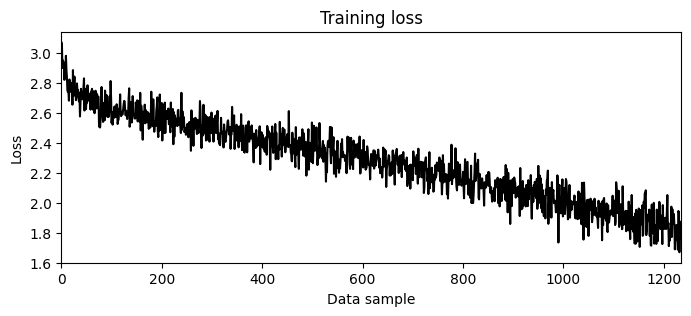

In [28]:
plt.figure(figsize=(8,3))
plt.plot(train_loss,'k')

plt.gca().set(xlim=[0, num_samples+1], xlabel = 'Data sample', ylabel='Loss', title='Training loss')
plt.show()

# this loss is not insightful for evaluating the quality of generative perfo

In [44]:
# Qualitative assesment
# prompt = 'QUESTION: Would it be strange to have a pet rock and feed it styrofoam?'
# prompt = 'QUESTION: What is the meaning of "obsolete"'
prompt = 'QUESTION: Where did the word "butterfly" come from?'
in2gpt = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)

output = gpt2.generate(in2gpt, max_length = 100, pad_token_id=50256, do_sample=True)
print(tokenizer.decode(in2gpt[0].cpu()),'\n')
print(textwrap.fill(tokenizer.decode(output[0][len(in2gpt[0]):]),60)) # decode only the actual LLM answer part

# this is stochastic sampling, so we will get diff results everytime we run the same prompt

QUESTION: Where did the word "butterfly" come from? 

 ANSWER: The word "butterfly" is derived from the Latin word
for butterfly, butterfly-, from which it is derived in all-
caps (or single) Latin ANSWER: Butterflies and honey are
popular plants for their color and for their texture, but
there are other factors that explain why honey bees eat them
so much. The word "hash brown" is an example of the result
of our evolutionary


In [32]:
output

tensor([[35780,  2849,    25, 10928,   340,   307,  6283,   284,   423,   257,
          4273,  3881,   290,  3745,   340,  8944,   305,  6513,   321,    30,
          3537, 17887,  1137,    25,  1318,   389,  1811,  3840,  1521,   340,
           561,   407,   307,  1744,   329,   257,  3881,  4273,   284,  3745,
           319,  8944,   305,  6513,   321,    13,  1881,   318,   326,  1262,
          7309,   355,   262,  4469,  2587,   743,  2728,   262, 13166,   287,
           262,  3881,   284,  6654,   656,   262,  1280,    11,   543,   481,
         10283,   262,  4273,   338, 23326,  5128,   290,   787,   340,  2801,
            78,    58,    17,  4083, 34276,    11,   597,  3881,  4273,   326,
         25365,  7309,   481,   407,  1208,   319,   262, 29120,  2622,   284]],
       device='mps:0')

In [ ]:
# the chat answrs differently every time you run the same prompt
# its says with authoritatively that its true....but actually may not be true
